Customer Churn Analysis and Prediction -- Exploratory Data Analysis

## Loading and Understanding the Dataset

In [40]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# loading dataset
df = pd.read_csv("../data/telco-customer-churn.csv")

Display some basic information by viewing first few rows of the dataset

In [3]:
# First few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Column and Data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Statistical Summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Judging by looking at the information. it seems multiple columns require transformation from object Dtype to numerical form. Furthermore, the dataset needs to be checked for missing values and outliers before proceeding with EDA.

## Data Preparation and cleaning. 

In [6]:
# Checking for missing values
missing_values = df.isnull().sum()
missing_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Converting the column'TotalCharges' to numeric since it is currently Object Dtype.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
# Checking for missing values after conversion
missing_values_after_conversion = df.isnull().sum()
missing_values_after_conversion

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

It seems their are 11 missing values in the column 'total charges' conversion to numeric Dtype.

In [10]:
# Showing entries with NaN in TotalCharges
total_charges_na = df[df['TotalCharges'].isna()]
total_charges_na

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [11]:
# Droping rows with missing TotalCharges values
df_cleaned = df.dropna(subset=['TotalCharges'])
df_cleaned.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Missing values within the column 'total charges' have been removed.

## Encoding Categorical Features

In [12]:
# Encode binary categorical variables
binary_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

binary_mapping = {
    "Yes": 1,
    "No": 0,
    "Male": 1,
    "Female": 0
}

df_cleaned[binary_columns] = df_cleaned[binary_columns].replace(binary_mapping)

C:\Users\Asus\AppData\Local\Temp\ipykernel_14180\2452159791.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned[binary_columns] = df_cleaned[binary_columns].replace(binary_mapping)
C:\Users\Asus\AppData\Local\Temp\ipykernel_14180\2452159791.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[binary_columns] = df_cleaned[binary_columns].replace(binary_mapping)


In [13]:
# One-hot encode remaining categorical variables
categorical_columns = df_cleaned.select_dtypes(include="object").columns.tolist()

categorical_columns.remove("customerID")

df_encoded = pd.get_dummies(
    df_cleaned,
    columns=categorical_columns,
    drop_first=True
)

In [14]:
df_encoded.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False


## Outlier Detection

In [19]:
# checking Numerical columns for outliers
numeric_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_cleaned[numeric_columns].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


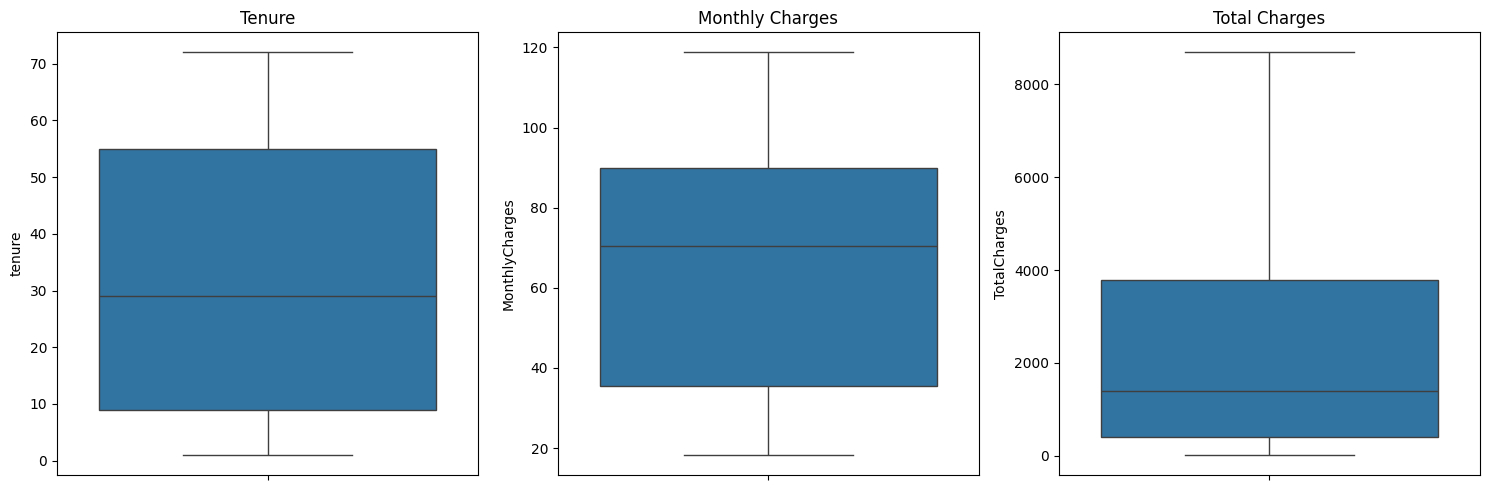

In [22]:
# Creating boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df_cleaned["tenure"], ax=axes[0])
axes[0].set_title("Tenure")

sns.boxplot(y=df_cleaned["MonthlyCharges"], ax=axes[1])
axes[1].set_title("Monthly Charges")

sns.boxplot(y=df_cleaned["TotalCharges"], ax=axes[2])
axes[2].set_title("Total Charges")

plt.tight_layout()
plt.show()

In [21]:
# Z-score 
z_scores = df_encoded[numeric_columns].apply(lambda x: stats.zscore(x))
outliers = (z_scores > 3) | (z_scores < -3)

# the number of outliers in each numerical column
outliers.sum()

tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64

The numerical features were examined individually for potential outliers.

No clearly invalid extreme observations were identified in `tenure` or `MonthlyCharges`. `TotalCharges` shows a wider and right-skewed distribution, which is expected because total charges accumulate over the duration of a customer's subscription.

Since the observed extreme values are plausible within the context of the dataset, no records were removed solely on the basis of these distributions.

## Feature Types

In [23]:
# Identifying columns
identifier_columns = ["customerID"]

numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_columns = [
    column
    for column in df_cleaned.columns
    if column not in numeric_columns + identifier_columns
]

print("Identifier columns:")
print(identifier_columns)

print("\nNumerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Identifier columns:
['customerID']

Numerical columns:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


The dataset contains three continuous numerical features: `tenure`, `MonthlyCharges`, and `TotalCharges`. The remaining customer attributes are categorical, including binary variables such as `SeniorCitizen`, `Partner`, and `Churn`.

`customerID` is treated as an identifier rather than an analytical feature because it uniquely identifies customers but does not describe customer behavior.

## Exploratory Data Analysis

Target distribution

In [24]:
# Churn Counts and Rates
churn_counts = df_cleaned["Churn"].value_counts()
churn_rates = df_cleaned["Churn"].value_counts(normalize=True) * 100

print("Churn Counts:")
print(churn_counts)

print("\nChurn Rates (%):")
print(churn_rates.round(2))

Churn Counts:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn Rates (%):
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


The target variable is imbalanced, with considerably more customers remaining than churning. This imbalance is important because accuracy alone may not provide a complete picture of predictive performance in the later modeling stage.

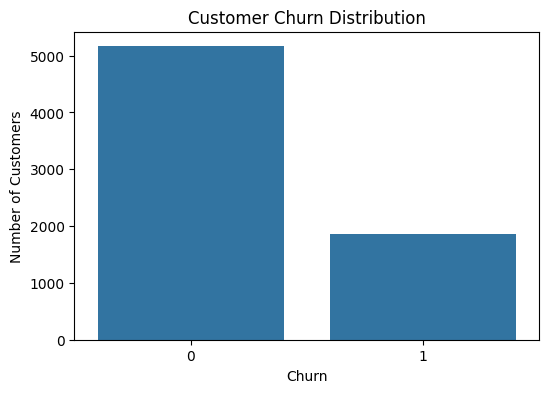

In [25]:
# Visualizing Churn Distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_cleaned,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Approximately 26.6% of customers in the dataset churned, while 73.4% remained with the service.

This class imbalance is important for the later modeling stage because a model could achieve relatively high accuracy by favoring the majority class. Therefore, evaluation metrics such as recall, precision, and F1-score should be considered alongside accuracy when assessing churn prediction models.

Numerical features vs Churn

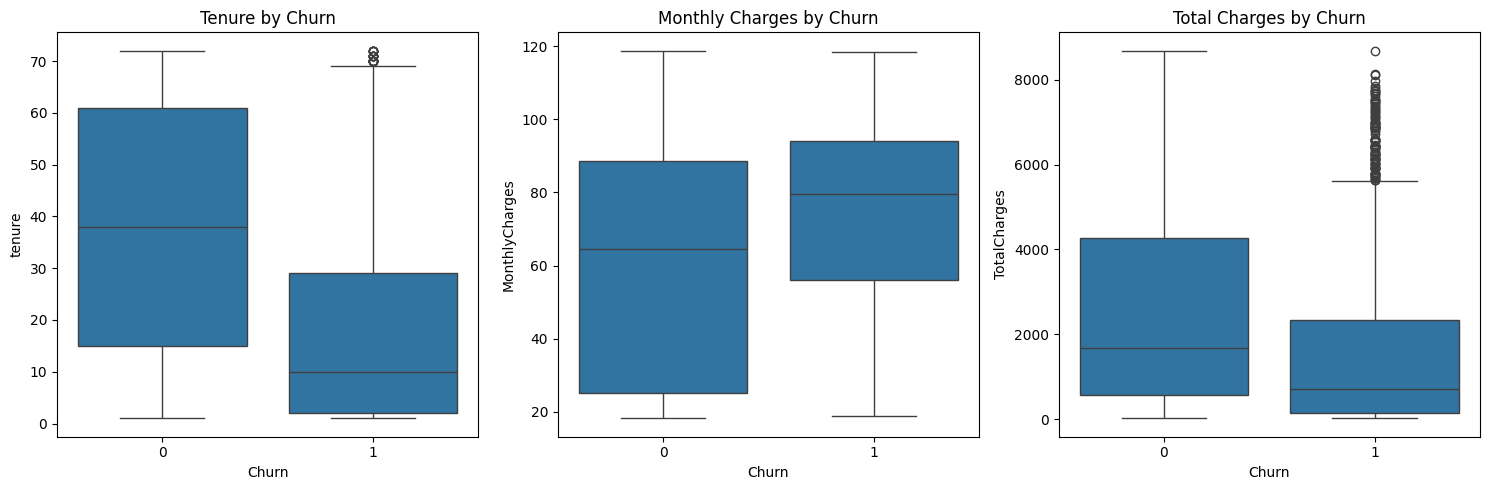

In [26]:
# Visualizing Churn Distribution by Tenure, Monthly Charges, and Total Charges
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df_cleaned, x="Churn", y="tenure", ax=axes[0])
axes[0].set_title("Tenure by Churn")

sns.boxplot(data=df_cleaned, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly Charges by Churn")

sns.boxplot(data=df_cleaned, x="Churn", y="TotalCharges", ax=axes[2])
axes[2].set_title("Total Charges by Churn")

plt.tight_layout()
plt.show()

### Numerical Features and Churn

The distributions show clear differences between customers who churned and those who remained.

- **Tenure:** Customers who churned generally had much shorter tenure, indicating that churn is more common among relatively newer customers.
- **Monthly Charges:** Churned customers tended to have higher monthly charges, suggesting that higher recurring costs may be associated with increased churn risk.
- **Total Charges:** Customers who churned generally had lower total charges. This is likely related to their shorter tenure, since customers who leave earlier have less time to accumulate charges.

These patterns suggest that tenure and pricing-related variables may be important factors in understanding customer churn.

### Contract Type and Churn

In [27]:
# Churn Rates by Contract Type
contract_churn = pd.crosstab(
    df_cleaned["Contract"],
    df_cleaned["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


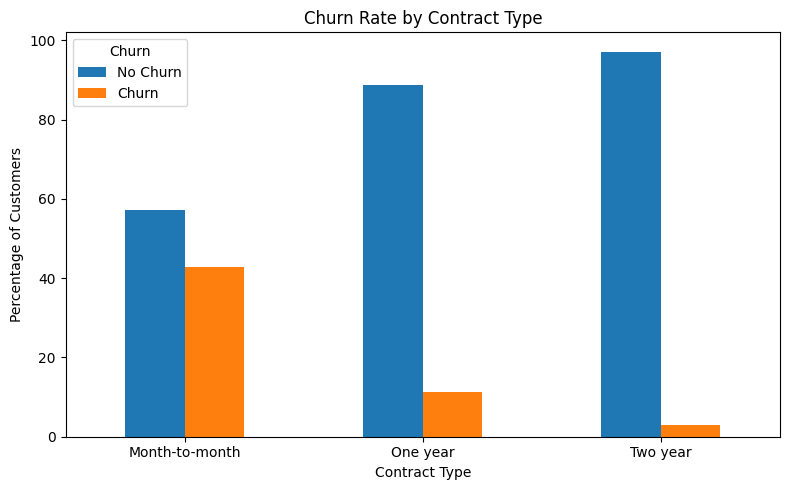

In [28]:
# Visualizing Churn Rates by Contract Type
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(["No Churn", "Churn"], title="Churn")

plt.tight_layout()
plt.show()

### Interpretation

Contract type shows a strong relationship with customer churn.

- **Month-to-month customers** have the highest churn rate at approximately **42.7%**.
- Customers with a **one-year contract** have a substantially lower churn rate of approximately **11.3%**.
- Customers with a **two-year contract** have the lowest churn rate at approximately **2.8%**.

This pattern suggests that customers with longer-term contractual commitments are considerably less likely to churn. Contract type may therefore be an important feature for identifying customers at higher risk of leaving.

### Payment Method and Churn

In [29]:
# Churn Rates by Payment Method
payment_churn = pd.crosstab(
    df_cleaned["PaymentMethod"],
    df_cleaned["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


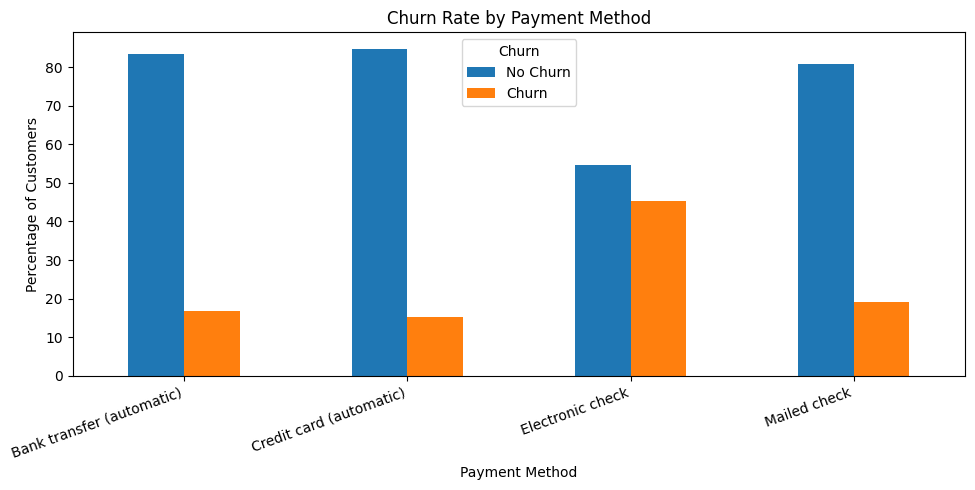

In [30]:
# Visualizing Churn Rates by Payment Method
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=20, ha="right")
plt.legend(["No Churn", "Churn"], title="Churn")

plt.tight_layout()
plt.show()

### Interpretation

Payment method is strongly associated with customer churn.

- Customers using **electronic check** have the highest churn rate at approximately **45.3%**.
- Customers using **bank transfer (automatic)** and **credit card (automatic)** have much lower churn rates, at approximately **16.7%** and **15.3%**, respectively.
- Customers using **mailed check** have a churn rate of approximately **19.2%**.

Electronic check users therefore appear to represent a higher-risk customer segment. However, this relationship should be interpreted as an association rather than evidence that the payment method itself directly causes churn.

### Service Features and Churn

In [31]:
# Churn Rates by Service Features
service_columns = [
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "OnlineBackup",
    "DeviceProtection"
]

for column in service_columns:
    churn_by_service = pd.crosstab(
        df_cleaned[column],
        df_cleaned["Churn"],
        normalize="index"
    ) * 100

    print(f"\n{column}")
    print(churn_by_service.round(2))


InternetService
Churn                0      1
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43

OnlineSecurity
Churn                    0      1
OnlineSecurity                   
No                   58.22  41.78
No internet service  92.57   7.43
Yes                  85.36  14.64

TechSupport
Churn                    0      1
TechSupport                      
No                   58.35  41.65
No internet service  92.57   7.43
Yes                  84.80  15.20

OnlineBackup
Churn                    0      1
OnlineBackup                     
No                   60.06  39.94
No internet service  92.57   7.43
Yes                  78.43  21.57

DeviceProtection
Churn                    0      1
DeviceProtection                 
No                   60.86  39.14
No internet service  92.57   7.43
Yes                  77.46  22.54


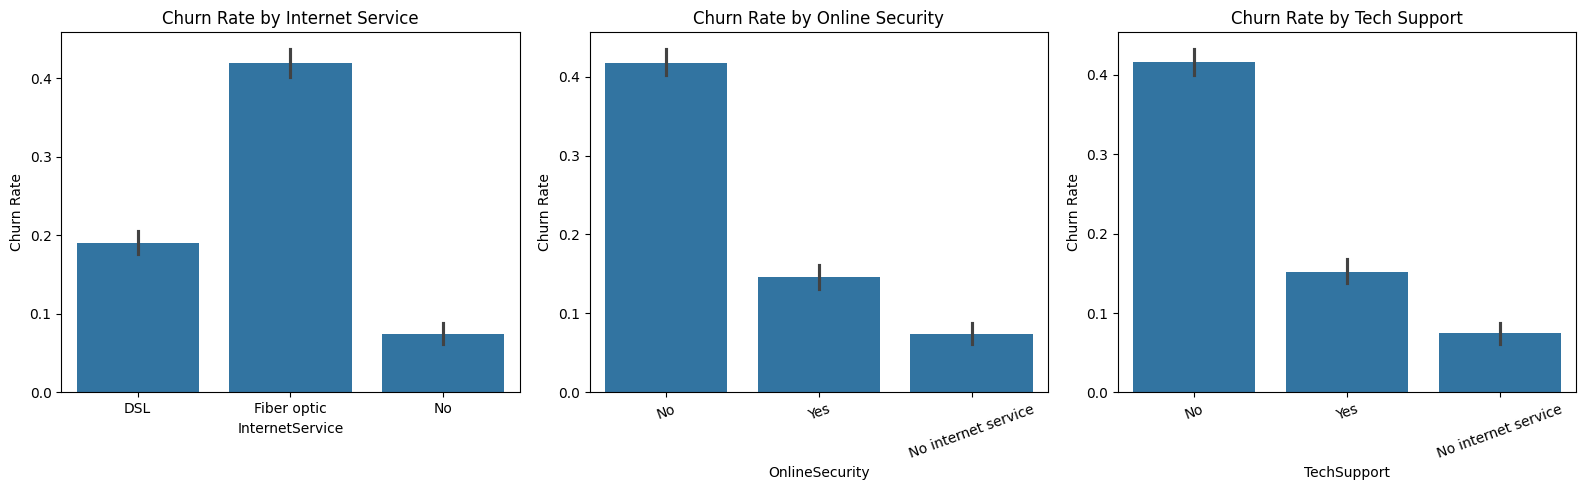

In [32]:
# Visualizing Churn Rates by Service Features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(
    data=df_cleaned,
    x="InternetService",
    y="Churn",
    ax=axes[0]
)
axes[0].set_title("Churn Rate by Internet Service")
axes[0].set_ylabel("Churn Rate")

sns.barplot(
    data=df_cleaned,
    x="OnlineSecurity",
    y="Churn",
    ax=axes[1]
)
axes[1].set_title("Churn Rate by Online Security")
axes[1].set_ylabel("Churn Rate")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(
    data=df_cleaned,
    x="TechSupport",
    y="Churn",
    ax=axes[2]
)
axes[2].set_title("Churn Rate by Tech Support")
axes[2].set_ylabel("Churn Rate")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Interpretation

Several service-related features show meaningful differences in churn behavior.

- Customers using **fiber optic internet** have a substantially higher churn rate than DSL customers.
- Customers without **Online Security** or **Tech Support** also show considerably higher churn rates than customers who subscribe to these services.
- Similar patterns are observed for **Online Backup** and **Device Protection**, although the differences are somewhat smaller.
- Customers with **no internet service** have the lowest churn rate across these service categories.

These results suggest that internet service type and the availability of support and protection services may be useful indicators of churn risk.

### Correlation Analysis

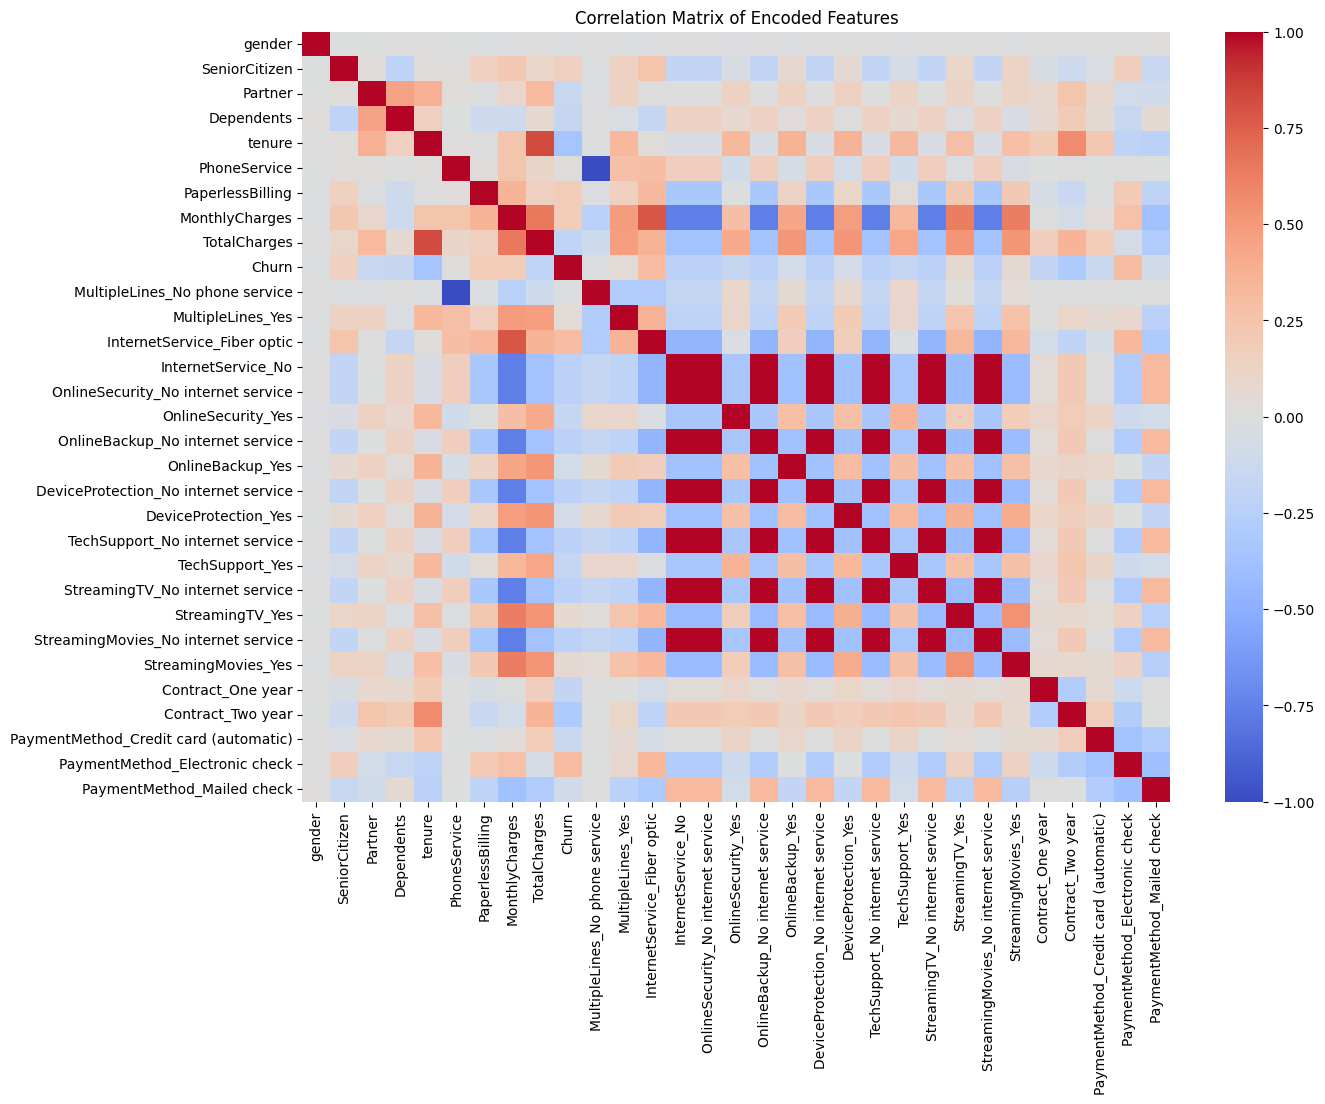

In [33]:
# Correlation Matrix of Encoded Features
correlation_matrix = df_encoded.drop(columns=["customerID"]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Encoded Features")
plt.show()

In [34]:
# Identifying Features with Strong Correlation to Churn
churn_correlations = (
    correlation_matrix["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
)

churn_correlations.head(15)

tenure                                 -0.354049
InternetService_Fiber optic             0.307463
Contract_Two year                      -0.301552
PaymentMethod_Electronic check          0.301455
StreamingTV_No internet service        -0.227578
TechSupport_No internet service        -0.227578
StreamingMovies_No internet service    -0.227578
DeviceProtection_No internet service   -0.227578
OnlineSecurity_No internet service     -0.227578
InternetService_No                     -0.227578
OnlineBackup_No internet service       -0.227578
TotalCharges                           -0.199484
MonthlyCharges                          0.192858
PaperlessBilling                        0.191454
Contract_One year                      -0.178225
Name: Churn, dtype: float64

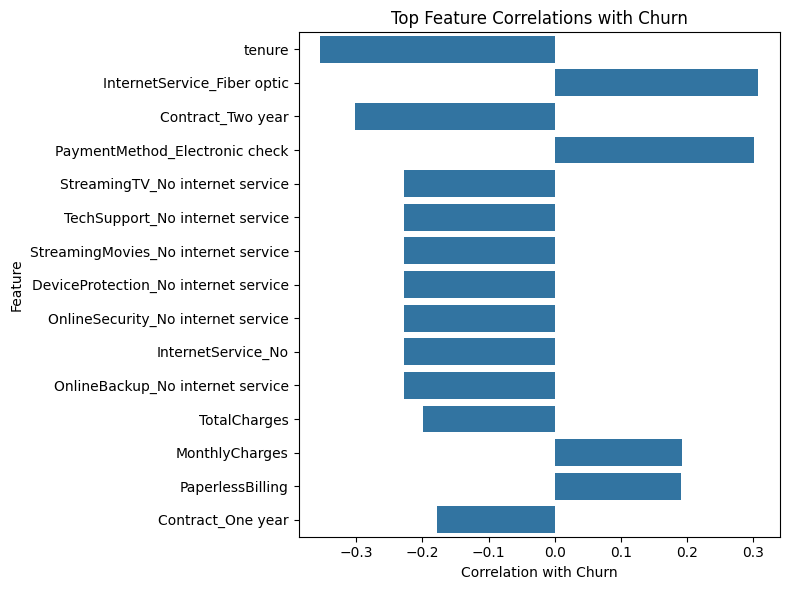

In [35]:
# Visualizing Top Feature Correlations with Churn
top_churn_correlations = churn_correlations.head(15)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=top_churn_correlations.values,
    y=top_churn_correlations.index
)

plt.title("Top Feature Correlations with Churn")
plt.xlabel("Correlation with Churn")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Interpretation

The correlation analysis supports several patterns identified earlier in the exploratory analysis.

- **Tenure** has the strongest negative correlation with churn, indicating that longer-tenured customers are generally less likely to leave.
- **Fiber optic internet service** and **electronic check payments** show relatively strong positive correlations with churn.
- **Two-year contracts** show a strong negative correlation with churn, consistent with the substantially lower churn rate observed among long-term contract customers.
- **Monthly charges** and **paperless billing** have weaker positive relationships with churn.
- **Total charges** are negatively correlated with churn, which is likely influenced by the relationship between total accumulated charges and customer tenure.

Several encoded features representing "No internet service" have identical correlations because they describe the same underlying customer condition. These should therefore not be interpreted as separate independent churn drivers.

Correlation measures association rather than causation, so these results are used to identify potentially informative features rather than establish direct causes of churn.

### Exploratory Feature Importance

In [36]:
# Prepare features and target
X = df_encoded.drop(columns=["Churn", "customerID"])
y = df_encoded["Churn"]

# Split the data while preserving the churn distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Fit a Decision Tree for exploratory feature importance
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

# Extract and rank feature importance
feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15)

tenure                                   0.212173
TotalCharges                             0.203654
MonthlyCharges                           0.180961
InternetService_Fiber optic              0.108336
Partner                                  0.023966
PaymentMethod_Electronic check           0.022685
OnlineSecurity_Yes                       0.022422
PaperlessBilling                         0.021856
gender                                   0.021104
OnlineBackup_Yes                         0.020573
Dependents                               0.019562
SeniorCitizen                            0.019318
TechSupport_Yes                          0.015541
MultipleLines_Yes                        0.015252
PaymentMethod_Credit card (automatic)    0.013811
dtype: float64

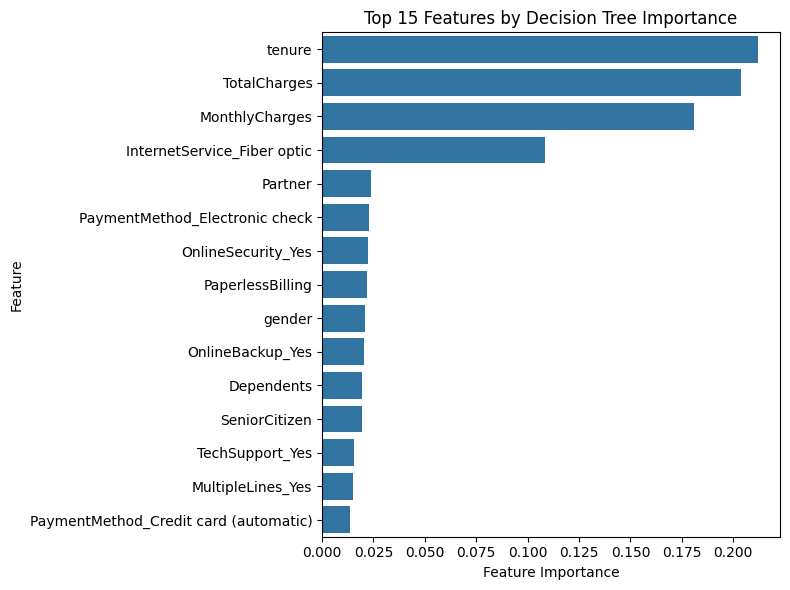

In [37]:
# Visualizing Top Features by Decision Tree Importance
top_features = feature_importance.head(15)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top 15 Features by Decision Tree Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Interpretation

The Decision Tree feature-importance analysis identifies `tenure`, `TotalCharges`, `MonthlyCharges`, and fiber optic internet service as the most influential features in separating churned and non-churned customers.

The results are generally consistent with the earlier exploratory analysis:

- **Tenure** is the most important feature, reinforcing the strong relationship between shorter customer tenure and churn.
- **Total Charges** and **Monthly Charges** are also highly influential, highlighting the importance of customer billing patterns.
- **Fiber optic internet service** has substantial importance, consistent with the higher churn rate observed among fiber optic customers.
- Features such as payment method, online security, and technical support contribute additional predictive information but have lower individual importance.

These importance scores are used here as an exploratory ranking rather than as a final measure of predictive performance.

## Train/Test Distribution Comparison

In [38]:
# Prepare features and target
X = df_encoded.drop(columns=["Churn", "customerID"])
y = df_encoded["Churn"]

# Create an 80/20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest churn distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set shape: (5625, 30)
Test set shape: (1407, 30)

Training churn distribution:
Churn
0    0.7342
1    0.2658
Name: proportion, dtype: float64

Test churn distribution:
Churn
0    0.7342
1    0.2658
Name: proportion, dtype: float64


### Interpretation

The dataset was split into training and test sets using an 80/20 ratio while stratifying on the churn target.

The churn distribution remains consistent across both subsets:

- **Training set:** 73.42% non-churn and 26.58% churn
- **Test set:** 73.42% non-churn and 26.58% churn

Maintaining the same class distribution helps ensure that both subsets are representative of the original dataset and provides a more reliable basis for later model evaluation.

In [39]:
# Create DataFrames for train and test sets with the target variable
train_df = X_train.copy()
train_df["Churn"] = y_train

test_df = X_test.copy()
test_df["Churn"] = y_test

In [41]:
# Generate a Sweetviz comparison report for the training and test datasets
comparison_report = sv.compare(
    [train_df, "Training Data"],
    [test_df, "Test Data"],
    target_feat="Churn"
)

comparison_report.show_html("../reports/comparison_report.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:02 -> (00:00 left) 


Report ../reports/comparison_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## Key Findings

The exploratory analysis identified several patterns associated with customer churn:

- **Customer tenure is strongly associated with churn.** Customers who churn tend to have substantially shorter tenure than customers who remain.
- **Contract type is one of the clearest churn indicators.** Month-to-month customers have a churn rate of approximately 42.7%, compared with 11.3% for one-year contracts and 2.8% for two-year contracts.
- **Electronic check customers show elevated churn**, with a churn rate of approximately 45.3%.
- **Fiber optic customers experience higher churn** than DSL customers.
- Customers without **Online Security** or **Tech Support** show considerably higher churn rates than customers who subscribe to those services.
- **MonthlyCharges** tend to be higher among churned customers.
- The Decision Tree feature-importance analysis highlights `tenure`, `TotalCharges`, `MonthlyCharges`, and fiber optic internet service as the most influential features in separating churned and non-churned customers.
- The churn target is moderately imbalanced, with approximately **26.6% churn** and **73.4% non-churn** customers.

## Limitations

Several limitations should be considered when interpreting this analysis:

- The dataset represents a snapshot of customer information and does not provide a detailed time-series history of customer behavior.
- The dataset contains basic demographic information but lacks richer customer attributes such as geographic location, customer satisfaction scores, complaint history, competitor activity, or detailed service-usage behavior.
- Relationships identified through exploratory analysis represent **associations rather than causal effects**. For example, customers using electronic check have a higher observed churn rate, but this does not establish that the payment method itself causes churn.
- Several service-related variables are closely related to one another. For example, customers without internet service receive the same `"No internet service"` category across multiple features, which creates correlated encoded variables.
- `TotalCharges` is strongly related to customer tenure, since customers with longer tenure naturally accumulate larger total charges.
- Feature importance from a single Decision Tree can be sensitive to the training sample and should be treated as an exploratory indicator rather than a definitive ranking of churn drivers.
- The class distribution is imbalanced, which should be considered carefully during predictive modeling and model evaluation.

## Next Step

The patterns identified in this exploratory analysis provide the foundation for the predictive modeling stage, where multiple classification algorithms are evaluated for their ability to identify customers at risk of churn.